In [109]:
#importing libraries
import os
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns
 


In [110]:
#Loading dataset

#instead of using csv file, i am loading data directly from url
data = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(data)


EDA

In [111]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [112]:
#converting "Survived" binary value to "yes" or "no"
def convert(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df["Survived"] = df["Survived"].apply(convert)

In [113]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:
#checking_data_types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 83.7+ KB


In [115]:
#checking statistical_summary
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [116]:
#checking null
df.isnull().sum()
 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [117]:
#checking missing values

missing = df.isnull().sum()
missing_percentage = (missing / len(df) * 100)

missing_data = pd.DataFrame({'Missing Count' : missing, 'Missing %': missing_percentage})
print('Missing Values')
print(missing_data[missing_data['Missing Count'] > 0])


Missing Values
          Missing Count  Missing %
Age                 177  19.865320
Cabin               687  77.104377
Embarked              2   0.224467


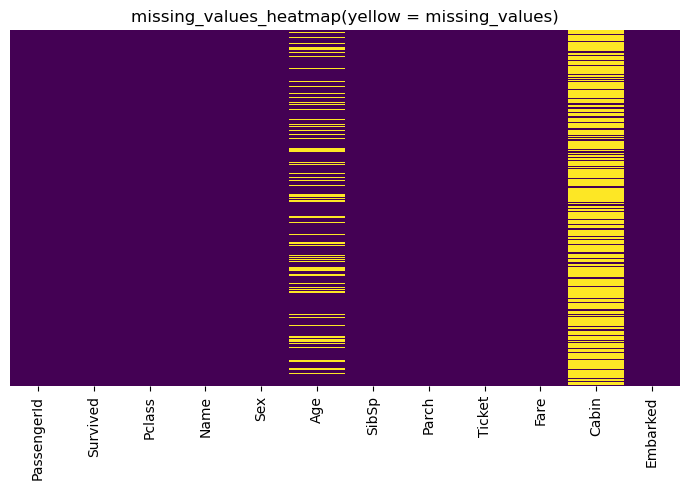

In [118]:
#Visualizing missing values using heat map
plt.figure(figsize=(7,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("missing_values_heatmap(yellow = missing_values)")
plt.tight_layout()
plt.show()


Visualizing

/tmp/ipykernel_19868/2199863961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


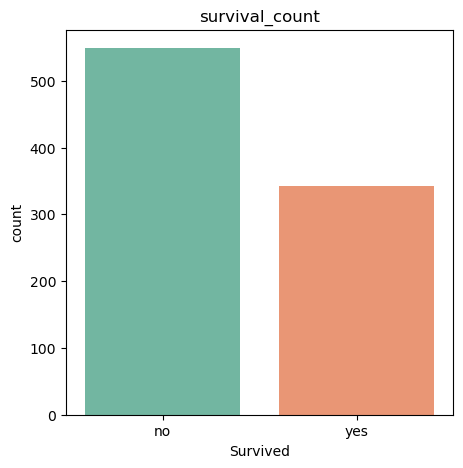

In [119]:
plt.figure(figsize=(5,5))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title("survival_count")
plt.show()

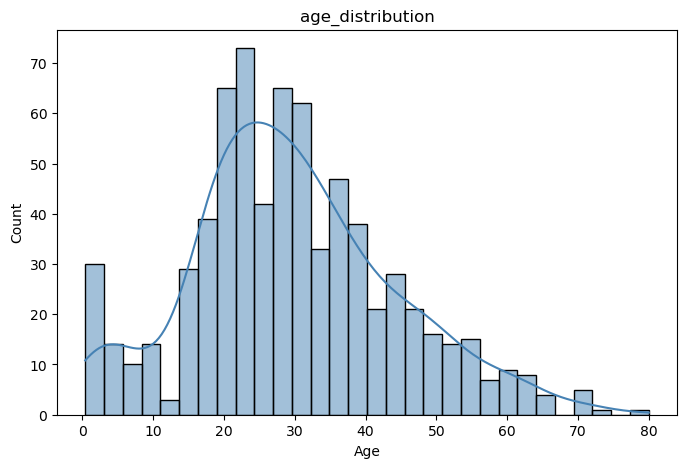

In [120]:
#age distribution 
plt.figure(figsize=(8,5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title("age_distribution")
plt.show()


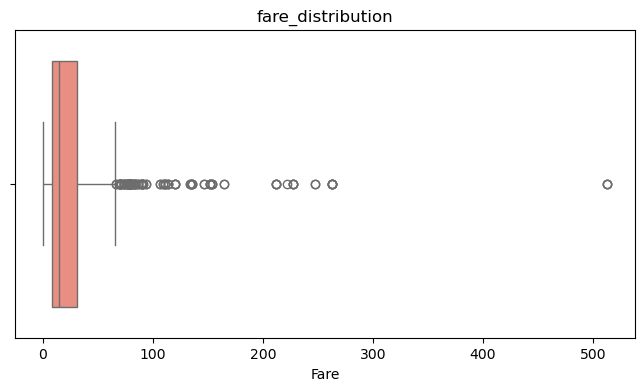

In [121]:
# Fare outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'], color='salmon')
plt.title('fare_distribution')
plt.show()

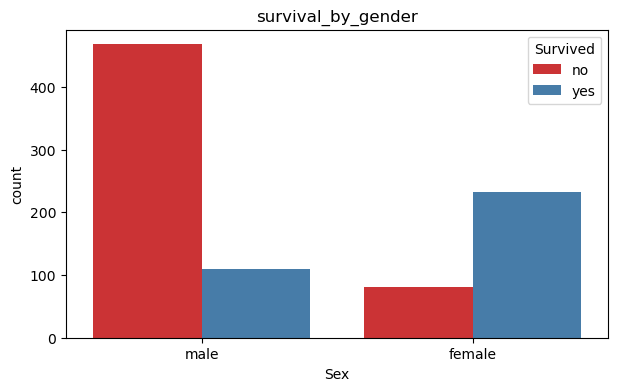

In [122]:
#survival by gender
plt.figure(figsize=(7,4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title("survival_by_gender")
plt.show()

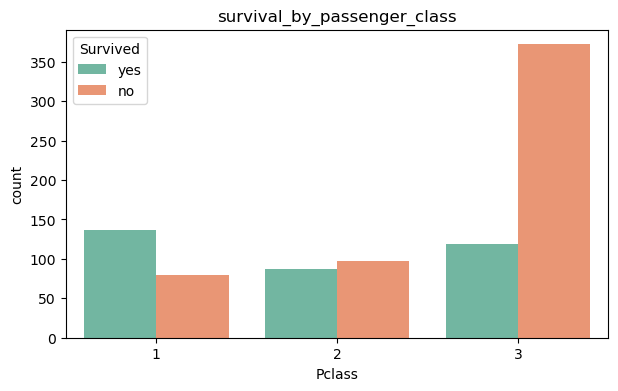

In [123]:
#survival by passenger class
plt.figure(figsize=(7,4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title("survival_by_passenger_class")
plt.show()

HANDELING MISSING VALUES

In [124]:
#filling age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [125]:
#filling Embarked with mode

df['Embarked'].fillna(df['Embarked'].mode()[0],)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [126]:
#dropping the cabin column, as earlier (in cell 11) I observed that it contains approximately 77% missing values
df.drop(columns=["Cabin"])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,no,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,no,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,yes,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,no,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,yes,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


ENCODE

In [127]:
#encoding sex
df['Sex'] = df['Sex'].map({'male': 1, 'female' : 0})

In [133]:
# encoding Survived column
df['Survived'] = df['Survived'].map({'yes': 1, 'no': 0})

In [129]:
#encode Embarked: S=0, C=1, Q=2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [130]:
#droping columns that are not useful for ML
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

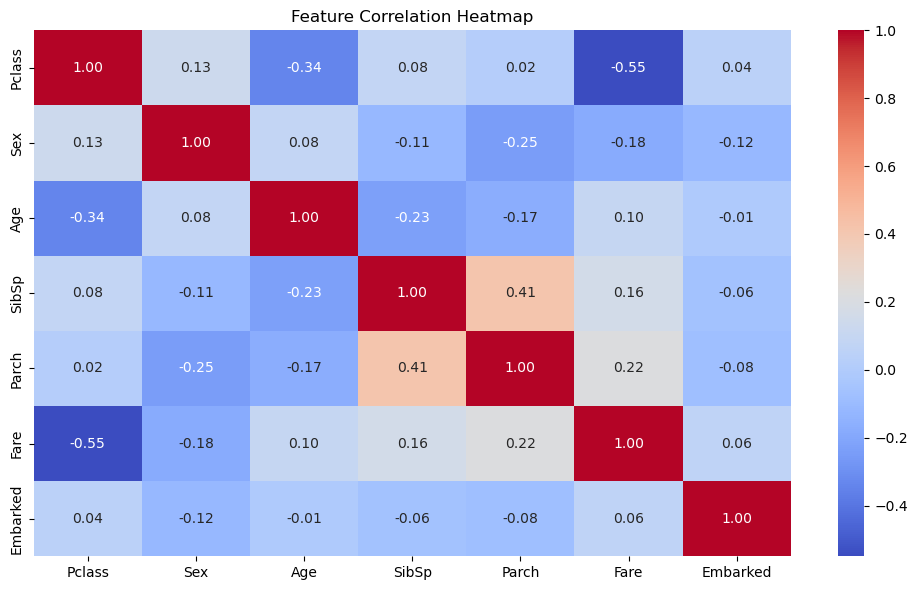

In [131]:
#correlation heatmap on cleaned data
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()

In [132]:
#saving cleaned data
os.makedirs('../cleaned', exist_ok=True)
df.to_csv('../cleaned/titanic_cleaned.csv', index=False)